In [1]:
# Import tools
import json
import shutil
import zipfile
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from google.colab import files
from IPython.display import display
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.lines import Line2D
from pathlib import Path
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components, minimum_spanning_tree, shortest_path
from scipy.spatial import Delaunay, cKDTree, ConvexHull
from scipy.stats import spearmanr
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import adjusted_rand_score


In [2]:
# Set plot style
plt.rc("text",usetex=False)
plt.rc("font",family="serif")
plt.rc("mathtext",fontset="cm")
plt.rc("font",size=13)
plt.rc("axes",labelsize=14)
plt.rc("xtick",labelsize=11)
plt.rc("ytick",labelsize=11)
plt.rc("legend",fontsize=11)
plt.rc("xtick",top=False,direction="out")
plt.rc("ytick",right=False,direction="out")
plt.rc("xtick.major",size=4.5,width=0.9)
plt.rc("ytick.major",size=4.5,width=0.9)
plt.rc("lines",linewidth=1.8,markersize=4.5,markeredgewidth=0.8)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
colors = {"blue":"#0072B2","orange":"#D55E00","green":"#009E73","purple":"#CC79A7","gray":"#7F7F7F"}


In [3]:
# Load graph export
archive = Path("graphs.zip")
if not archive.exists():
    uploaded = files.upload()
    archive = Path(next(iter(uploaded)))
data = Path("graph_data")
shutil.rmtree(data,ignore_errors=True)
data.mkdir()
with zipfile.ZipFile(archive) as bundle:
    required = ["nodes.csv","edges.csv","orders.csv","parameters.json"]
    missing = [name for name in required if name not in bundle.namelist()]
    if len(missing)>0:
        raise FileNotFoundError("Missing graph files: "+", ".join(missing))
    bundle.extractall(data)
nodes = pd.read_csv(data/"nodes.csv",dtype={"site":str})
edges = pd.read_csv(data/"edges.csv",dtype={"source":str,"target":str})
orders = pd.read_csv(data/"orders.csv",dtype=str)
with open(data/"parameters.json") as file:
    params = json.load(file)
siteindex = {site:i for i,site in enumerate(nodes["site"])}
n = len(nodes)
W = np.zeros((n,n))
for row in edges.itertuples(index=False):
    i = siteindex[row.source]
    j = siteindex[row.target]
    W[i,j] = float(row.weight)
    W[j,i] = float(row.weight)
laplacian = np.diag(W.sum(axis=1))-W
values,vectors = np.linalg.eigh(laplacian)
values = np.maximum(values,0)
K = int(params["modes"])
clock = np.asarray(params["times"],dtype=float)
horizon = float(params["horizon"])
weights = nodes["weight"].to_numpy(dtype=float)
basis = vectors[:,:K]
lam = values[:K]
scale = float(lam[-1])
decay = np.exp(-np.outer(clock/scale,lam))
blocks = basis[:,None,:]*decay[None,:,:]
info = np.einsum("nrk,nrl->nkl",blocks,blocks)
beta = 0.01*np.trace(info.sum(axis=0))/K
target = np.exp(-(horizon/scale)*lam)*(basis.T@weights)
taps = [siteindex[site] for site in orders["taps"]]
r = blocks.shape[1]
mainmodel = {"blocks":blocks,"info":info,"target":target,"beta":beta}
print("Stations:",n)
print("Edges:",len(edges))
print("Modes:",K)
print("Readings per sensor:",r)


Saving 02-graphs.zip to 02-graphs.zip
Stations: 104
Edges: 664
Modes: 40
Readings per sensor: 3


In [4]:
# Audit graph model
selected = taps[:10]
M = beta*np.eye(K)+info[selected].sum(axis=0)
mainrisk = np.sqrt(beta*target@np.linalg.solve(M,target)/(target@target))
blockerror = np.max(np.abs(info-np.einsum("nrk,nrl->nkl",blocks,blocks)))
parts = connected_components(csr_matrix((W>0).astype(int)),directed=False,return_labels=False)
checks = {
    "104 stations":n==104,
    "664 edges":len(edges)==664,
    "Connected graph":parts==1,
    "Ten TAPS sensors":len(selected)==10 and len(set(selected))==10,
    "Regularization reproduced":np.isclose(beta,float(params["beta"]),rtol=0,atol=1e-14),
    "Main risk reproduced":np.isclose(mainrisk,0.13289871775756013,rtol=0,atol=1e-12),
    "Block identity":blockerror<1e-12
}
audit = pd.DataFrame({"check":checks.keys(),"passed":checks.values()})
display(audit)
assert all(checks.values())
print("Main risk:",f"{mainrisk:.6f}")


,check,passed
0,104 stations,True
1,664 edges,True
2,Connected graph,True
3,Ten TAPS sensors,True
4,Regularization reproduced,True
5,Main risk reproduced,True
6,Block identity,True


Main risk: 0.132899


In [5]:
# Define target tools
def target_state(model,selected):
    info = model["info"]
    target = model["target"]
    beta = float(model["beta"])
    M = beta*np.eye(len(target))
    if len(selected)>0:
        M = M+info[selected].sum(axis=0)
    h = np.linalg.solve(M,target)
    value = beta*target@h/(target@target)
    return M,h,value
def target_risk(model,selected):
    return np.sqrt(target_state(model,selected)[2])
def greedy_order(model,budget=10):
    selected = []
    for step in range(budget):
        raw,retention,gain,units = candidate_geometry(model,selected)
        remaining = [v for v in range(len(gain)) if v not in selected]
        selected.append(remaining[int(np.argmax(gain[remaining]))])
    return selected,target_risk(model,selected)


In [6]:
# Define candidate geometry
def candidate_geometry(model,selected):
    blocks = model["blocks"]
    info = model["info"]
    target = model["target"]
    beta = float(model["beta"])
    n,r,K = blocks.shape
    M,h,value = target_state(model,selected)
    chol = np.linalg.cholesky(M)
    norm = target@target
    flat = blocks.reshape(n*r,K)
    solved = np.linalg.solve(M,flat.T).T.reshape(n,r,K)
    response = np.einsum("nrk,k->nr",blocks,h)
    overlap = np.eye(r)[None,:,:]+np.einsum("nrk,nsk->nrs",blocks,solved)
    adjusted = np.linalg.solve(overlap,response[...,None])[...,0]
    response2 = np.einsum("nr,nr->n",response,response)
    raw = beta*response2/norm
    retention = np.einsum("nr,nr->n",response,adjusted)
    retention = retention/np.maximum(response2,np.finfo(float).eps)
    gain = raw*retention
    correction = np.einsum("nrk,nr->nk",solved,adjusted)
    signatures = correction@chol
    signorm = np.linalg.norm(signatures,axis=1)
    units = signatures/np.maximum(signorm[:,None],np.finfo(float).eps)
    return raw,retention,gain,units


In [7]:
# Audit marginal gains
rows = []
selected = []
for step in range(10):
    M,h,value = target_state(mainmodel,selected)
    raw,retention,gain,units = candidate_geometry(mainmodel,selected)
    remaining = [v for v in range(n) if v not in selected]
    chosen = taps[step]
    best = remaining[int(np.argmax(gain[remaining]))]
    errors = []
    for v in remaining:
        nextvalue = target_state(mainmodel,selected+[v])[2]
        errors.append(abs(gain[v]-(value-nextvalue)))
    rows.append({
        "step":step+1,
        "chosen":nodes.loc[chosen,"site"],
        "best":nodes.loc[best,"site"],
        "choice_matches":chosen==best,
        "maximum_gain_error":max(errors),
        "minimum_gain":gain[remaining].min()
    })
    selected.append(chosen)
formulaaudit = pd.DataFrame(rows)
display(formulaaudit)
print("All choices match:",formulaaudit["choice_matches"].all())
print("Maximum gain error:",f'{formulaaudit["maximum_gain_error"].max():.3e}')


,step,chosen,best,choice_matches,maximum_gain_error,minimum_gain
0,1,06-001-0009,06-001-0009,True,1.249001e-15,1.733097e-13
1,2,06-097-0004,06-097-0004,True,2.400966e-16,4.695521e-14
2,3,06-081-1001,06-081-1001,True,1.741229e-16,1.143292e-14
3,4,06-053-0002,06-053-0002,True,1.114831e-16,9.096908e-13
4,5,06-001-0015,06-001-0015,True,7.301909e-17,1.635643e-12
5,6,06-013-0002,06-013-0002,True,3.642919e-17,2.979217e-12
6,7,06-001-0007,06-001-0007,True,3.076352e-17,1.801448e-12
7,8,06-075-0005,06-075-0005,True,2.949030e-17,1.419544e-12
8,9,06-001-0012,06-001-0012,True,1.859897e-17,1.761293e-12
9,10,06-085-0006,06-085-0006,True,2.031681e-17,1.877220e-12


All choices match: True
Maximum gain error: 1.249e-15


In [8]:
# Decompose TAPS gains
rows = []
selected = []
for step,chosen in enumerate(taps[:10],1):
    raw,retention,gain,units = candidate_geometry(mainmodel,selected)
    remaining = [v for v in range(n) if v not in selected]
    rawleader = remaining[int(np.argmax(raw[remaining]))]
    scale = max(len(remaining)-1,1)
    rawrank = 1+int(np.sum(raw[remaining]>raw[chosen]+1e-12))
    retentionrank = 1+int(np.sum(retention[remaining]>retention[chosen]+1e-12))
    gainrank = 1+int(np.sum(gain[remaining]>gain[chosen]+1e-12))
    rows.append({
        "step":step,
        "site":nodes.loc[chosen,"site"],
        "raw_rank":rawrank,
        "retention_rank":retentionrank,
        "gain_rank":gainrank,
        "raw_percentile":1-(rawrank-1)/scale,
        "retention_percentile":1-(retentionrank-1)/scale,
        "raw_response":raw[chosen],
        "retention":retention[chosen],
        "gain":gain[chosen],
        "raw_leader":nodes.loc[rawleader,"site"],
        "leader_retention":retention[rawleader],
        "same_station":chosen==rawleader
    })
    selected.append(chosen)
gainpath = pd.DataFrame(rows)
display(gainpath)


,step,site,raw_rank,retention_rank,gain_rank,raw_percentile,retention_percentile,raw_response,retention,gain,raw_leader,leader_retention,same_station
0,1,06-001-0009,9,34,1,0.922330,0.679612,8.119071,0.093497,0.759111,06-075-0005,0.077097,False
1,2,06-097-0004,1,103,1,1.000000,0.000000,7.159441,0.011298,0.080887,06-097-0004,0.011298,True
2,3,06-081-1001,11,26,1,0.900990,0.752475,0.369640,0.210261,0.077721,06-087-0007,0.049942,False
3,4,06-053-0002,2,76,1,0.990000,0.250000,0.483701,0.036155,0.017488,06-053-0008,0.025803,False
4,5,06-001-0015,9,7,1,0.919192,0.939394,0.041795,0.492243,0.020573,06-099-0005,0.035561,False
5,6,06-013-0002,10,7,1,0.908163,0.938776,0.028755,0.457410,0.013153,06-079-8002,0.010985,False
6,7,06-001-0007,9,10,1,0.917526,0.907216,0.010537,0.377531,0.003978,06-079-8002,0.010864,False
7,8,06-075-0005,5,7,1,0.958333,0.937500,0.008440,0.583213,0.004923,06-079-8002,0.010992,False
8,9,06-001-0012,10,3,1,0.905263,0.978947,0.002889,0.761618,0.002200,06-079-8002,0.010973,False
9,10,06-085-0006,8,8,1,0.925532,0.925532,0.004575,0.503717,0.002304,06-079-8002,0.010966,False


In [9]:
# Build graph distances
lat = np.radians(nodes["lat"].to_numpy())
lon = np.radians(nodes["lon"].to_numpy())
dlat = lat[:,None]-lat[None,:]
dlon = lon[:,None]-lon[None,:]
a = np.sin(dlat/2)**2+np.cos(lat[:,None])*np.cos(lat[None,:])*np.sin(dlon/2)**2
geodistance = 2*6371.0088*np.arcsin(np.sqrt(np.clip(a,0,1)))
length = np.full((n,n),np.inf)
mask = W>0
length[mask] = np.maximum(-np.log(W[mask]),1e-12)
np.fill_diagonal(length,0)
pathdistance = shortest_path(length,directed=False)
laplacian = np.diag(W.sum(axis=1))-W
inverse = np.linalg.pinv(laplacian,rcond=1e-12)
diag = np.diag(inverse)
resistance = np.maximum(diag[:,None]+diag[None,:]-2*inverse,0)
print("Shortest paths finite:",np.isfinite(pathdistance).all())
print("Resistance symmetric:",np.allclose(resistance,resistance.T))


Shortest paths finite: True
Resistance symmetric: True


In [10]:
# Define transfer model
def build_model(modes,horizon):
    basis = vectors[:,:modes]
    lam = values[:modes]
    scale = float(lam[-1])
    decay = np.exp(-np.outer(clock/scale,lam))
    blocks = basis[:,None,:]*decay[None,:,:]
    info = np.einsum("nrk,nrl->nkl",blocks,blocks)
    beta = 0.01*np.trace(info.sum(axis=0))/modes
    coeff = basis.T@weights
    target = np.exp(-(horizon/scale)*lam)*coeff
    gaps = (horizon-clock)/scale
    field = np.column_stack([basis@(np.exp(-gap*lam)*coeff) for gap in gaps])
    mass = np.sum(field**2,axis=1)
    profile = field**2/np.maximum(mass[:,None],np.finfo(float).eps)
    spaces = [basis[:,1:]*np.exp(-gap*lam[1:]) for gap in gaps]
    heatspace = np.hstack(spaces)/np.sqrt(len(spaces))
    square = np.sum(heatspace**2,axis=1)
    heat = np.sqrt(np.maximum(square[:,None]+square[None,:]-2*heatspace@heatspace.T,0))
    np.fill_diagonal(heat,0)
    return {
        "blocks":blocks,
        "info":info,
        "target":target,
        "beta":beta,
        "mass":mass,
        "profile":profile,
        "heat":heat
    }


In [11]:
# Build transfer conditions
casekeys = [
    (modes,float(horizon))
    for modes in [20,30,40,50]
    for horizon in [0.5,1,2]
]
conditionmodels = {}
for modes,horizon in casekeys:
    model = build_model(modes,horizon)
    order,risk = greedy_order(model,10)
    model["order"] = order
    model["risk"] = risk
    conditionmodels[(modes,horizon)] = model
maincase = conditionmodels[(40,1.0)]
print("Conditions:",len(conditionmodels))
print("Main order reproduced:",maincase["order"]==taps[:10])
print("Main risk:",f'{maincase["risk"]:.6f}')


Conditions: 12
Main order reproduced: True
Main risk: 0.132899


In [12]:
# Measure transfer states
rows = []
for modes,horizon in casekeys:
    model = conditionmodels[(modes,horizon)]
    selected = []
    for step in range(10):
        raw,retention,gain,units = candidate_geometry(model,selected)
        remaining = [v for v in range(n) if v not in selected]
        chosen = remaining[int(np.argmax(gain[remaining]))]
        rawleader = remaining[int(np.argmax(raw[remaining]))]
        nextselected = selected+[chosen]
        rawnext,retnext,gainnext,unitsnext = candidate_geometry(model,nextselected)
        later = [v for v in remaining if v!=chosen]
        interaction = (gain[later]-gainnext[later])/(gain[chosen]+gainnext[later])
        similarity = units[later]@units[chosen]
        metrics = {
            "signature":similarity,
            "geographic":-geodistance[chosen,later],
            "shortest":-pathdistance[chosen,later],
            "resistance":-resistance[chosen,later],
            "heat":-model["heat"][chosen,later]
        }
        correlations = {name:spearmanr(interaction,values).statistic for name,values in metrics.items()}
        ranks = pd.Series(similarity).rank(method="first")
        groups = pd.qcut(ranks,4,labels=False)
        gap = interaction[groups==3].mean()-interaction[groups==0].mean()
        rows.append({
            "modes":modes,
            "horizon":horizon,
            "step":step+1,
            "signature":correlations["signature"],
            "geographic":correlations["geographic"],
            "shortest":correlations["shortest"],
            "resistance":correlations["resistance"],
            "heat":correlations["heat"],
            "interaction_gap":gap,
            "raw_leader_skipped":chosen!=rawleader,
            "higher_retention":retention[chosen]>retention[rawleader]
        })
        selected = nextselected
transferstates = pd.DataFrame(rows)


In [13]:
# Summarize transfer states
geometrycols = ["geographic","shortest","resistance","heat"]
transferstates["best_geometry"] = transferstates[geometrycols].max(axis=1)
transferstates["signature_best"] = transferstates["signature"]>transferstates["best_geometry"]
transfersummary = pd.DataFrame([{
    "states":len(transferstates),
    "mean_signature_correlation":transferstates["signature"].mean(),
    "signature_best_states":int(transferstates["signature_best"].sum()),
    "positive_interaction_gaps":int((transferstates["interaction_gap"]>0).sum()),
    "raw_leaders_skipped":int(transferstates["raw_leader_skipped"].sum()),
    "higher_retention_when_skipped":int(transferstates.loc[transferstates["raw_leader_skipped"],"higher_retention"].sum())
}])
display(transfersummary)
assert len(transferstates)==120
assert int(transferstates["signature_best"].sum())==120
assert int((transferstates["interaction_gap"]>0).sum())==120
assert int(transferstates["raw_leader_skipped"].sum())==111
assert int(transferstates.loc[transferstates["raw_leader_skipped"],"higher_retention"].sum())==111
assert np.isclose(transferstates["signature"].mean(),0.8892016510530946,atol=1e-12)


,states,mean_signature_correlation,signature_best_states,positive_interaction_gaps,raw_leaders_skipped,higher_retention_when_skipped
0,120,0.889202,120,120,111,111


In [14]:
# Define band helpers
raw0,retention0,gain0,units0 = candidate_geometry(maincase,[])
def standardize(values):
    values = np.asarray(values,dtype=float)
    mean = values.mean(axis=0)
    scale = values.std(axis=0)
    return (values-mean)/np.maximum(scale,np.finfo(float).eps)
def equal_mass_bands(values,count):
    values = np.asarray(values,dtype=float)
    order = np.argsort(-values,kind="stable")
    midpoint = (np.cumsum(values[order])-0.5*values[order])/values.sum()
    labels = np.minimum(np.floor(count*midpoint).astype(int)+1,count)
    bands = np.empty(len(values),dtype=int)
    bands[order] = labels
    return bands
def distance_bands(values,count,method):
    values = np.asarray(values,dtype=float)
    if method=="Linear":
        boundaries = np.linspace(values.min(),values.max(),count+1)[1:-1]
    elif method=="Log":
        transformed = np.log1p(values)
        boundaries = np.expm1(np.linspace(transformed.min(),transformed.max(),count+1)[1:-1])
    else:
        model = KMeans(n_clusters=count,n_init=50,random_state=0)
        rawlabels = model.fit_predict(values[:,None])
        centers = model.cluster_centers_[:,0]
        order = np.argsort(centers)
        labels = np.zeros(len(values),dtype=int)
        for band,cluster in enumerate(order,1):
            labels[rawlabels==cluster] = band
        return labels
    return np.digitize(values,boundaries)+1


In [15]:
# Screen connected regions
lograw = np.log(np.maximum(raw0,np.finfo(float).eps))
logmass = np.log(np.maximum(maincase["mass"],np.finfo(float).eps))
profile = maincase["profile"]
xy = standardize(np.column_stack([
    nodes["lon"].to_numpy(),
    nodes["lat"].to_numpy()
]))
features = {
    "Response":standardize(lograw[:,None]),
    "Influence":standardize(np.column_stack([logmass,profile])),
    "Response profile":standardize(np.column_stack([lograw,logmass,profile]))
}
connectivity = csr_matrix((W>0).astype(int))
wardrows = []
for name,targetfeatures in features.items():
    for spaceweight in [0,0.25,0.5,1.0]:
        values = targetfeatures if spaceweight==0 else np.column_stack([targetfeatures,spaceweight*xy])
        for bands in [3,4,5,6]:
            labels = AgglomerativeClustering(
                n_clusters = bands,
                linkage = "ward",
                connectivity = connectivity
            ).fit_predict(values)
            means = np.array([raw0[labels==group].mean() for group in range(bands)])
            order = np.argsort(-means)
            ordered = np.zeros(n,dtype=int)
            for band,group in enumerate(order,1):
                ordered[labels==group] = band
            allocation = np.bincount(ordered[np.asarray(taps[:10])],minlength=bands+1)[1:]
            wardrows.append({
                "features":name,
                "space_weight":spaceweight,
                "bands":bands,
                "minimum_size":np.bincount(ordered,minlength=bands+1)[1:].min(),
                "occupied_bands":int(np.sum(allocation>0)),
                "allocation":"-".join(allocation.astype(str))
            })
wardscreen = pd.DataFrame(wardrows)


In [16]:
# Screen distance shells
targetlat = np.sum(nodes["lat"].to_numpy()*weights)/weights.sum()
targetlon = np.sum(nodes["lon"].to_numpy()*weights)/weights.sum()
targetlatrad = np.radians(targetlat)
targetlonrad = np.radians(targetlon)
targeta = (
    np.sin((lat-targetlatrad)/2)**2
    + np.cos(lat)*np.cos(targetlatrad)*np.sin((lon-targetlonrad)/2)**2
)
geographicdistance = 2*6371.0088*np.arcsin(np.sqrt(np.clip(targeta,0,1)))
anchor = int(np.argmin(geographicdistance))
edgeu,edgev = np.where(W>0)
edgelength = geodistance[edgeu,edgev]
lengthgraph = csr_matrix((edgelength,(edgeu,edgev)),shape=(n,n))
graphdistance = shortest_path(lengthgraph,directed=False,indices=anchor)
shellrows = []
for distance_name,distance_values in {
    "Geographic":geographicdistance,
    "Graph path":graphdistance
}.items():
    for method in ["Linear","Log","1D k-means"]:
        for bands in [3,4,5,6]:
            labels = distance_bands(distance_values,bands,method)
            if len(np.unique(labels))!=bands:
                continue
            allocation = np.bincount(labels[np.asarray(taps[:10])],minlength=bands+1)[1:]
            shellrows.append({
                "distance":distance_name,
                "method":method,
                "bands":bands,
                "minimum_size":np.bincount(labels,minlength=bands+1)[1:].min(),
                "occupied_bands":int(np.sum(allocation>0)),
                "allocation":"-".join(allocation.astype(str))
            })
shellscreen = pd.DataFrame(shellrows)


In [17]:
# Build spanning tree
mask = W>0
treecost = np.zeros_like(W)
treecost[mask] = np.maximum(-np.log(np.clip(W[mask],1e-12,1)),1e-9)
tree = minimum_spanning_tree(csr_matrix(treecost))
tree = (tree+tree.T).tocoo()
treeadj = [[] for v in range(n)]
treeedges = []
for u,v in zip(tree.row,tree.col):
    u = int(u)
    v = int(v)
    if u>=v:
        continue
    treeadj[u].append(v)
    treeadj[v].append(u)
    treeedges.append((u,v,float(W[u,v])))
print("Tree edges:",len(treeedges))


Tree edges: 103


In [18]:
# Define connected cuts
def tree_component(start,nodeset,blocked):
    blocked_u,blocked_v = blocked
    seen = {start}
    stack = [start]
    while len(stack)>0:
        u = stack.pop()
        for v in treeadj[u]:
            if v not in nodeset:
                continue
            if (u==blocked_u and v==blocked_v) or (u==blocked_v and v==blocked_u):
                continue
            if v not in seen:
                seen.add(v)
                stack.append(v)
    return seen
def choose_cut(nodeset,parts,mass,minimum,penalty):
    leftparts = parts//2
    rightparts = parts-leftparts
    targetfraction = leftparts/parts
    totalmass = mass[list(nodeset)].sum()
    internal = [edge for edge in treeedges if edge[0] in nodeset and edge[1] in nodeset]
    maximum = max(edge[2] for edge in internal)
    best = None
    bestkey = None
    for required in [minimum,1]:
        for u,v,strength in internal:
            first = tree_component(u,nodeset,(u,v))
            second = nodeset-first
            for left,right in [(first,second),(second,first)]:
                if len(left)<leftparts*required or len(right)<rightparts*required:
                    continue
                fraction = mass[list(left)].sum()/totalmass
                balance = abs(fraction-targetfraction)
                size = abs(len(left)/len(nodeset)-targetfraction)
                edgepenalty = penalty*strength/maximum
                key = (balance+0.01*size+edgepenalty,balance,edgepenalty,min(u,v),max(u,v))
                if bestkey is None or key<bestkey:
                    bestkey = key
                    best = (left,right)
        if best is not None:
            break
    return best


In [19]:
# Define connected partitions
def tree_partition(nodeset,parts,mass,minimum,penalty):
    if parts==1:
        return [sorted(nodeset)]
    leftparts = parts//2
    rightparts = parts-leftparts
    left,right = choose_cut(nodeset,parts,mass,minimum,penalty)
    return (
        tree_partition(left,leftparts,mass,minimum,penalty)
        + tree_partition(right,rightparts,mass,minimum,penalty)
    )
def balanced_labels(raw,bands,target_fraction,cut_penalty):
    targetmass = raw/raw.sum()
    coveragemass = np.full(n,1/n)
    mass = target_fraction*targetmass+(1-target_fraction)*coveragemass
    partitions = tree_partition(set(range(n)),bands,mass,5,cut_penalty)
    means = np.array([raw[region].mean() for region in partitions])
    order = np.argsort(-means)
    labels = np.zeros(n,dtype=int)
    for band,index in enumerate(order,1):
        labels[partitions[index]] = band
    return labels,mass


In [20]:
# Screen balanced bands
rows = []
balancedlabels = {}
for target_fraction in [0.50,0.65,0.80,0.90,0.97]:
    for cut_penalty in [0.00,0.02,0.05]:
        for bands in [3,4,5,6]:
            labels,mass = balanced_labels(raw0,bands,target_fraction,cut_penalty)
            sizes = np.bincount(labels,minlength=bands+1)[1:]
            shares = np.array([mass[labels==band].sum() for band in range(1,bands+1)])
            ideal = 1/bands
            allocation = np.bincount(labels[np.asarray(taps[:10])],minlength=bands+1)[1:]
            rows.append({
                "target_fraction":target_fraction,
                "cut_penalty":cut_penalty,
                "bands":bands,
                "minimum_size":sizes.min(),
                "sizes":"-".join(sizes.astype(str)),
                "relative_imbalance":np.max(np.abs(shares-ideal))/ideal,
                "occupied_bands":int(np.sum(allocation>0)),
                "allocation":"-".join(allocation.astype(str))
            })
            balancedlabels[(target_fraction,cut_penalty,bands)] = labels
balancedscreen = pd.DataFrame(rows)
band_specs = {
    "Target-balanced 3":{
        "bands":3,
        "target_fraction":0.50,
        "cut_penalty":0.05
    },
    "Target-balanced 4":{
        "bands":4,
        "target_fraction":0.50,
        "cut_penalty":0.00
    }
}
display(balancedscreen[
    (
        balancedscreen["target_fraction"].eq(0.50)
        & balancedscreen["cut_penalty"].isin([0.00,0.05])
        & balancedscreen["bands"].isin([3,4])
    )
])


,target_fraction,cut_penalty,bands,minimum_size,sizes,relative_imbalance,occupied_bands,allocation
0,0.5,0.00,3,8,8-46-50,0.054514,3,4-3-3
1,0.5,0.00,4,7,7-7-43-47,0.063186,4,3-5-1-1
8,0.5,0.05,3,9,9-45-50,0.067429,3,4-3-3
9,0.5,0.05,4,6,6-7-44-47,0.086631,4,2-5-2-1


In [21]:
# Build bands by condition
bandrows = []
labelstore = {}
for name,spec in band_specs.items():
    for modes,horizon in casekeys:
        model = conditionmodels[(modes,horizon)]
        raw,retention,gain,units = candidate_geometry(model,[])
        labels,mass = balanced_labels(
            raw,
            spec["bands"],
            spec["target_fraction"],
            spec["cut_penalty"]
        )
        labelstore[(name,modes,horizon)] = labels
        sizes = np.bincount(labels,minlength=spec["bands"]+1)[1:]
        shares = np.array([mass[labels==band].sum() for band in range(1,spec["bands"]+1)])
        allocation = np.bincount(labels[np.asarray(model["order"])],minlength=spec["bands"]+1)[1:]
        ideal = 1/spec["bands"]
        bandrows.append({
            "definition":name,
            "modes":modes,
            "horizon":horizon,
            "bands":spec["bands"],
            "sizes":"-".join(sizes.astype(str)),
            "minimum_size":sizes.min(),
            "relative_imbalance":np.max(np.abs(shares-ideal))/ideal,
            "occupied_bands":int(np.sum(allocation>0)),
            "allocation":"-".join(allocation.astype(str))
        })
balancedbands = pd.DataFrame(bandrows)
display(balancedbands)


,definition,modes,horizon,bands,sizes,minimum_size,relative_imbalance,occupied_bands,allocation
0,Target-balanced 3,20,0.5,3,8-46-50,8,0.047292,3,5-2-3
1,Target-balanced 3,20,1.0,3,8-46-50,8,0.055199,3,4-2-4
2,Target-balanced 3,20,2.0,3,9-46-49,9,0.055499,3,3-4-3
3,Target-balanced 3,30,0.5,3,8-46-50,8,0.044927,3,4-3-3
4,Target-balanced 3,30,1.0,3,8-46-50,8,0.045978,3,4-2-4
5,Target-balanced 3,30,2.0,3,9-45-50,9,0.070563,3,3-4-3
6,Target-balanced 3,40,0.5,3,9-45-50,9,0.062015,3,6-2-2
7,Target-balanced 3,40,1.0,3,9-45-50,9,0.067429,3,4-3-3
8,Target-balanced 3,40,2.0,3,9-45-50,9,0.070274,3,5-3-2
9,Target-balanced 3,50,0.5,3,9-45-50,9,0.031438,3,6-1-3


In [22]:
# Summarize band stability
rows = []
for definition,group in balancedbands.groupby("definition"):
    frequency = group["allocation"].value_counts()
    rows.append({
        "definition":definition,
        "bands":int(group["bands"].iloc[0]),
        "minimum_size":int(group["minimum_size"].min()),
        "maximum_imbalance":group["relative_imbalance"].max(),
        "minimum_occupied_bands":int(group["occupied_bands"].min()),
        "distinct_allocations":group["allocation"].nunique(),
        "modal_allocation":frequency.index[0],
        "modal_cases":int(frequency.iloc[0])
    })
bandstability = pd.DataFrame(rows)
display(bandstability)


,definition,bands,minimum_size,maximum_imbalance,minimum_occupied_bands,distinct_allocations,modal_allocation,modal_cases
0,Target-balanced 3,3,8,0.070563,3,7,5-2-3,2
1,Target-balanced 4,4,6,0.071785,2,11,4-4-1-1,2


In [23]:
# Define quota tools
def run_quota(model,labels,quota):
    labels = np.asarray(labels,dtype=int)
    quota = np.asarray(quota,dtype=int)
    selected = []
    counts = np.zeros(len(quota),dtype=int)
    available = np.ones(len(labels),dtype=bool)
    for step in range(quota.sum()):
        raw,retention,gain,units = candidate_geometry(model,selected)
        allowed = available & (counts[labels-1]<quota[labels-1])
        if not np.any(allowed):
            return selected,np.nan,False
        chosen = int(np.argmax(np.where(allowed,gain,-np.inf)))
        selected.append(chosen)
        available[chosen] = False
        counts[labels[chosen]-1] +=  1
    return selected,target_risk(model,selected),True
def learned_quota(frame,qcols):
    frequency = frame.groupby(qcols).size().reset_index(name="frequency")
    maximum = frequency["frequency"].max()
    candidates = frequency[frequency["frequency"].eq(maximum)].copy()
    training = frame[qcols].to_numpy(dtype=int)
    distances = []
    for values in candidates[qcols].itertuples(index=False,name=None):
        candidate = np.asarray(values,dtype=int)
        distances.append(np.abs(training-candidate).sum(axis=1).mean())
    candidates["mean_l1"] = distances
    return candidates.sort_values(["mean_l1",*qcols]).iloc[0][qcols].to_numpy(dtype=int)


In [24]:
# Test held-out quotas
rows = []
for definition,spec in band_specs.items():
    bandcount = spec["bands"]
    qcols = [f"q{band}" for band in range(1,bandcount+1)]
    data = balancedbands[balancedbands["definition"].eq(definition)].copy()
    for band in range(1,bandcount+1):
        data[f"q{band}"] = data["allocation"].str.split("-").str[band-1].astype(int)
    for modes,horizon in casekeys:
        heldout = data["modes"].eq(modes) & data["horizon"].eq(horizon)
        quota = learned_quota(data[~heldout],qcols)
        model = conditionmodels[(modes,horizon)]
        labels = labelstore[(definition,modes,horizon)]
        selected,risk,feasible = run_quota(model,labels,quota)
        rows.append({
            "definition":definition,
            "modes":modes,
            "horizon":horizon,
            "learned_quota":"-".join(quota.astype(str)),
            "feasible":feasible,
            "risk_ratio":risk/model["risk"] if feasible else np.nan,
            "taps_overlap":len(set(selected)&set(model["order"])) if feasible else 0
        })
quotaheldout = pd.DataFrame(rows)
display(quotaheldout)


,definition,modes,horizon,learned_quota,feasible,risk_ratio,taps_overlap
0,Target-balanced 3,20,0.5,4-3-3,True,1.001778,9
1,Target-balanced 3,20,1.0,4-3-3,True,1.007325,9
2,Target-balanced 3,20,2.0,5-2-3,True,1.041309,7
3,Target-balanced 3,30,0.5,5-2-3,True,1.002494,9
4,Target-balanced 3,30,1.0,4-3-3,True,1.008652,9
5,Target-balanced 3,30,2.0,5-2-3,True,1.037619,8
6,Target-balanced 3,40,0.5,4-3-3,True,1.067688,8
7,Target-balanced 3,40,1.0,5-2-3,True,1.026485,8
8,Target-balanced 3,40,2.0,4-3-3,True,1.001538,9
9,Target-balanced 3,50,0.5,4-3-3,True,1.076978,8


In [25]:
# Summarize quota transfer
rows = []
for definition,group in quotaheldout.groupby("definition"):
    valid = group[group["feasible"]]
    frequency = group["learned_quota"].value_counts()
    medianratio = valid["risk_ratio"].median()
    worstratio = valid["risk_ratio"].max()
    rows.append({
        "definition":definition,
        "distinct_quotas":group["learned_quota"].nunique(),
        "most_common_quota":frequency.index[0],
        "most_common_cases":int(frequency.iloc[0]),
        "median_risk_ratio":medianratio,
        "mean_risk_ratio":valid["risk_ratio"].mean(),
        "worst_risk_ratio":worstratio,
        "within_5_percent":int((valid["risk_ratio"]<=1.05).sum()),
        "within_10_percent":int((valid["risk_ratio"]<=1.10).sum()),
        "mean_taps_overlap":valid["taps_overlap"].mean(),
        "passes_transfer":(
            len(valid)==12
            and medianratio<=1.05
            and worstratio<=1.10
            and group["learned_quota"].nunique()<=2
        )
    })
quotatransfer = pd.DataFrame(rows).sort_values("worst_risk_ratio")
display(quotatransfer)


,definition,distinct_quotas,most_common_quota,most_common_cases,median_risk_ratio,mean_risk_ratio,worst_risk_ratio,within_5_percent,within_10_percent,mean_taps_overlap,passes_transfer
0,Target-balanced 3,2,4-3-3,8,1.017568,1.025532,1.076978,10,12,8.5,True
1,Target-balanced 4,2,4-4-1-1,10,1.025324,1.025904,1.086374,10,12,8.0,True


In [26]:
# Audit three-band stability
bandname = "Target-balanced 3"
mainlabels = labelstore[(bandname,40,1.0)]
rows = []
for modes,horizon in casekeys:
    labels = labelstore[(bandname,modes,horizon)]
    allocation = np.bincount(labels[np.asarray(conditionmodels[(modes,horizon)]["order"])],minlength=4)[1:]
    rows.append({
        "modes":modes,
        "horizon":horizon,
        "node_agreement":np.mean(labels==mainlabels),
        "adjusted_rand":adjusted_rand_score(mainlabels,labels),
        "occupied_bands":int(np.sum(allocation>0)),
        "allocation":"-".join(allocation.astype(str))
    })
threebandstability = pd.DataFrame(rows)
transferresult = quotatransfer[quotatransfer["definition"].eq(bandname)].iloc[0]
mainsizes = np.bincount(mainlabels,minlength=4)[1:]
display(threebandstability)
assert mainsizes.tolist()==[9,45,50]
assert (threebandstability["occupied_bands"]==3).all()
assert np.isclose(threebandstability["node_agreement"].mean(),0.9951923076923078,atol=1e-12)
assert np.isclose(threebandstability["node_agreement"].min(),0.9807692307692307,atol=1e-12)
assert np.isclose(threebandstability["adjusted_rand"].mean(),0.9897331064263288,atol=1e-12)
assert np.isclose(threebandstability["adjusted_rand"].min(),0.9578427473511468,atol=1e-12)
assert transferresult["most_common_quota"]=="4-3-3"
assert bool(transferresult["passes_transfer"])
print("Main sizes:","-".join(mainsizes.astype(str)))
print("Mean agreement:",f'{threebandstability["node_agreement"].mean():.3f}')
print("Minimum agreement:",f'{threebandstability["node_agreement"].min():.3f}')
print("Transferable quota:",transferresult["most_common_quota"])
print("Worst-case increase:",f'{100*(transferresult["worst_risk_ratio"]-1):.2f}%')


,modes,horizon,node_agreement,adjusted_rand,occupied_bands,allocation
0,20,0.5,0.990385,0.979739,3,5-2-3
1,20,1.0,0.990385,0.979739,3,4-2-4
2,20,2.0,0.980769,0.957843,3,3-4-3
3,30,0.5,0.990385,0.979739,3,4-3-3
4,30,1.0,0.990385,0.979739,3,4-2-4
5,30,2.0,1.000000,1.000000,3,3-4-3
6,40,0.5,1.000000,1.000000,3,6-2-2
7,40,1.0,1.000000,1.000000,3,4-3-3
8,40,2.0,1.000000,1.000000,3,5-3-2
9,50,0.5,1.000000,1.000000,3,6-1-3


Main sizes: 9-45-50
Mean agreement: 0.995
Minimum agreement: 0.981
Transferable quota: 4-3-3
Worst-case increase: 7.70%


In [27]:
# Compare band definitions
rawstrata = equal_mass_bands(raw0,4)
rawcomponents = []
for band in range(1,5):
    members = np.flatnonzero(rawstrata==band)
    subgraph = connectivity[members][:,members]
    rawcomponents.append(connected_components(subgraph,directed=False,return_labels=False))
comparison = pd.DataFrame([
    {
        "definition":"Raw-response strata",
        "spatial":False,
        "connected":all(value==1 for value in rawcomponents),
        "maximum_occupied_bands":int(
            np.sum(np.bincount(rawstrata[np.asarray(taps[:10])],minlength=5)[1:]>0)
        ),
        "accepted":False
    },
    {
        "definition":"Connected Ward regions",
        "spatial":True,
        "connected":True,
        "maximum_occupied_bands":int(wardscreen["occupied_bands"].max()),
        "accepted":False
    },
    {
        "definition":"Target-centered shells",
        "spatial":True,
        "connected":False,
        "maximum_occupied_bands":int(shellscreen["occupied_bands"].max()),
        "accepted":False
    },
    {
        "definition":"Target-balanced 3",
        "spatial":True,
        "connected":True,
        "maximum_occupied_bands":int(
            balancedbands.loc[balancedbands["definition"].eq("Target-balanced 3"),"occupied_bands"].min()
        ),
        "accepted":bool(transferresult["passes_transfer"])
    }
])
display(comparison)


,definition,spatial,connected,maximum_occupied_bands,accepted
0,Raw-response strata,False,True,4,False
1,Connected Ward regions,True,True,1,False
2,Target-centered shells,True,False,4,False
3,Target-balanced 3,True,True,3,True


In [28]:
# Define spacing design
def run_spacing(model,distance,kind,threshold,budget=10):
    selected = []
    available = np.ones(n,dtype=bool)
    for step in range(budget):
        raw,retention,gain,units = candidate_geometry(model,selected)
        if len(selected)==0:
            similarity = np.full(n,np.nan)
            separation = np.full(n,np.inf)
        else:
            similarity = np.max(units[selected]@units.T,axis=0)
            separation = np.min(distance[:,selected],axis=1)
        allowed = available.copy()
        if kind=="Geographic":
            allowed = allowed & (separation>=threshold-1e-12)
        elif len(selected)>0:
            allowed = allowed & (similarity<=threshold+1e-12)
        if not np.any(allowed):
            return selected,np.nan,False
        chosen = int(np.argmax(np.where(allowed,gain,-np.inf)))
        selected.append(chosen)
        available[chosen] = False
    return selected,target_risk(model,selected),True


In [29]:
# Run spacing transfer
spacinggrids = {
    "Geographic":[0,5,10,15,20,22.5,25,27.5,30],
    "Functional":[1.00,0.99,0.98,0.97,0.96,0.95,0.94,0.92,0.90]
}
rows = []
for modes,horizon in casekeys:
    model = conditionmodels[(modes,horizon)]
    for constraint,grid in spacinggrids.items():
        for threshold in grid:
            selected,risk,feasible = run_spacing(
                model,
                geodistance,
                constraint,
                threshold
            )
            rows.append({
                "modes":modes,
                "horizon":horizon,
                "constraint":constraint,
                "threshold":threshold,
                "feasible":feasible,
                "risk_ratio":risk/model["risk"] if feasible else np.nan,
                "taps_overlap":len(set(selected)&set(model["order"])) if feasible else 0
            })
spacingtransfer = pd.DataFrame(rows)


In [30]:
# Summarize spacing transfer
rows = []
for keys,group in spacingtransfer.groupby(["constraint","threshold"]):
    constraint,threshold = keys
    valid = group[group["feasible"]]
    rows.append({
        "constraint":constraint,
        "threshold":threshold,
        "feasible_cases":len(valid),
        "median_risk_ratio":valid["risk_ratio"].median(),
        "mean_risk_ratio":valid["risk_ratio"].mean(),
        "worst_risk_ratio":valid["risk_ratio"].max(),
        "within_5_percent":int((valid["risk_ratio"]<=1.05).sum()),
        "within_10_percent":int((valid["risk_ratio"]<=1.10).sum()),
        "mean_taps_overlap":valid["taps_overlap"].mean()
    })
spacingsummary = pd.DataFrame(rows).sort_values(["constraint","threshold"])
display(spacingsummary)


,constraint,threshold,feasible_cases,median_risk_ratio,mean_risk_ratio,worst_risk_ratio,within_5_percent,within_10_percent,mean_taps_overlap
0,Functional,0.90,12,1.103328,1.148353,1.421755,3,5,6.416667
1,Functional,0.92,12,1.068624,1.118544,1.421755,5,8,6.916667
2,Functional,0.94,12,1.019685,1.048704,1.189183,7,10,7.333333
3,Functional,0.95,12,1.019685,1.049182,1.194501,7,10,7.500000
4,Functional,0.96,12,1.002524,1.025004,1.136971,9,11,8.000000
5,Functional,0.97,12,1.001429,1.018483,1.136971,10,11,8.000000
6,Functional,0.98,12,1.000927,1.010239,1.064915,10,12,8.166667
7,Functional,0.99,12,1.000000,0.998743,1.004528,12,12,8.750000
8,Functional,1.00,12,1.000000,1.000000,1.000000,12,12,10.000000
9,Geographic,0.00,12,1.000000,1.000000,1.000000,12,12,10.000000


In [31]:
# Select spacing limits
rows = []
for tolerance in [1.01,1.05,1.10]:
    geographic = spacingsummary[
        spacingsummary["constraint"].eq("Geographic")
        & spacingsummary["feasible_cases"].eq(12)
        & spacingsummary["worst_risk_ratio"].le(tolerance)
    ]
    functional = spacingsummary[
        spacingsummary["constraint"].eq("Functional")
        & spacingsummary["feasible_cases"].eq(12)
        & spacingsummary["worst_risk_ratio"].le(tolerance)
    ]
    georow = geographic.sort_values("threshold").iloc[-1]
    funcrow = functional.sort_values("threshold").iloc[0]
    rows.append({
        "risk_tolerance":tolerance-1,
        "geographic_threshold_km":georow["threshold"],
        "geographic_worst_ratio":georow["worst_risk_ratio"],
        "functional_threshold":funcrow["threshold"],
        "functional_worst_ratio":funcrow["worst_risk_ratio"]
    })
spacinglimits = pd.DataFrame(rows)
display(spacinglimits)


,risk_tolerance,geographic_threshold_km,geographic_worst_ratio,functional_threshold,functional_worst_ratio
0,0.01,10.0,1.004528,0.99,1.004528
1,0.05,20.0,1.032557,0.99,1.004528
2,0.10,20.0,1.032557,0.98,1.064915


In [32]:
# Build map territories
maplon = nodes["lon"].to_numpy(dtype=float)
maplat = nodes["lat"].to_numpy(dtype=float)
lonmin = maplon.min()-0.35
lonmax = maplon.max()+0.35
latmin = maplat.min()-0.30
latmax = maplat.max()+0.30
gridlon = np.linspace(lonmin,lonmax,520)
gridlat = np.linspace(latmin,latmax,520)
gridlon2,gridlat2 = np.meshgrid(gridlon,gridlat)
coordinates = np.column_stack([maplon,maplat])
gridpoints = np.column_stack([gridlon2.ravel(),gridlat2.ravel()])
hull = Delaunay(coordinates)
inside = hull.find_simplex(gridpoints)>=0
nearest = cKDTree(coordinates).query(gridpoints,k=1)[1]
gridbands = np.full(len(gridpoints),np.nan)
gridbands[inside] = mainlabels[nearest[inside]]
gridbands = gridbands.reshape(gridlon2.shape)
bandcolors = ["#D95F02","#1B9E77","#7570B3"]
bandcmap = ListedColormap(bandcolors)
bandnorm = BoundaryNorm([0.5,1.5,2.5,3.5],bandcmap.N)
mapselected = np.asarray(maincase["order"],dtype=int)
out = Path("bands_results")
shutil.rmtree(out,ignore_errors=True)
out.mkdir()


In [33]:
# Draw band map
edgeu,edgev = np.where(np.triu(W>0,1))
hulledges = coordinates[ConvexHull(coordinates).vertices]
hulledges = np.vstack([hulledges,hulledges[0]])

def draw_partition(ax,xlimits,ylimits,marker_size):
    ax.pcolormesh(
        gridlon2,
        gridlat2,
        np.ma.masked_invalid(gridbands),
        cmap=bandcmap,
        norm=bandnorm,
        shading="auto",
        alpha=0.82,
        rasterized=True
    )

    ax.contour(
        gridlon2,
        gridlat2,
        np.ma.masked_invalid(gridbands),
        levels=[1.5,2.5],
        colors="white",
        linewidths=1.1
    )

    for u,v in zip(edgeu,edgev):
        crossing = mainlabels[u]!=mainlabels[v]
        ax.plot(
            [maplon[u],maplon[v]],
            [maplat[u],maplat[v]],
            color="black" if crossing else "0.45",
            linewidth=0.90 if crossing else 0.40,
            alpha=0.75 if crossing else 0.35,
            zorder=2
        )

    ax.scatter(
        maplon,
        maplat,
        s=8,
        facecolors="white",
        edgecolors="0.60",
        linewidths=0.3,
        zorder=3
    )

    ax.scatter(
        maplon[mapselected],
        maplat[mapselected],
        s=marker_size,
        facecolors="white",
        edgecolors="black",
        linewidths=1.35,
        zorder=4
    )

    ax.plot(
        hulledges[:,0],
        hulledges[:,1],
        color="0.30",
        linewidth=1.0,
        zorder=5
    )

    ax.set_xlim(xlimits)
    ax.set_ylim(ylimits)
    ax.set_aspect(1/np.cos(np.radians(maplat.mean())))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

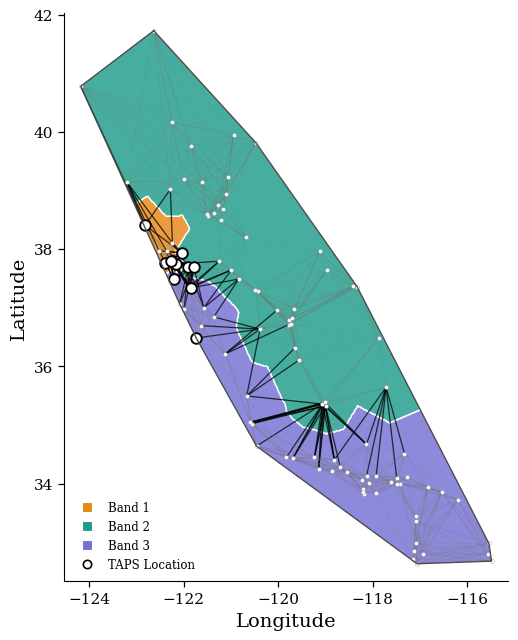

In [34]:
# Plot spatial bands
bandcolors = ["#E68613","#1F9D8A","#7570D4"]
bandcmap = ListedColormap(bandcolors)
bandnorm = BoundaryNorm([0.5,1.5,2.5,3.5],bandcmap.N)

fig,ax = plt.subplots(figsize=(5.8,6.6))
draw_partition(ax,(lonmin,lonmax),(latmin,latmax),58)

handles = []

for band in [1,2,3]:
    handles.append(
        Line2D(
            [0],[0],
            marker="s",
            linestyle="",
            markerfacecolor=bandcolors[band-1],
            markeredgecolor="white",
            markersize=7,
            label=f"Band {band}"
        )
    )

handles.append(
    Line2D(
        [0],[0],
        marker="o",
        linestyle="",
        markerfacecolor="white",
        markeredgecolor="black",
        markeredgewidth=1.2,
        markersize=6,
        label="TAPS Location"
    )
)

ax.legend(handles=handles,loc="lower left",frameon=False,fontsize=8.5)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

fig.tight_layout()
fig.savefig(out/"target_balanced_bands.png",dpi=450,bbox_inches="tight",pad_inches=0.04,facecolor="white")
plt.show()

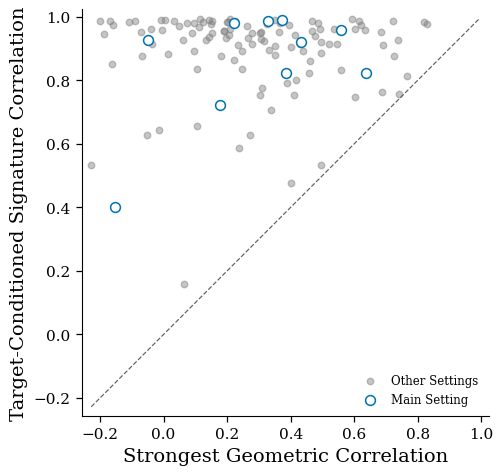

In [35]:
# Plot signature advantage
mainmask = transferstates["modes"].eq(40)&transferstates["horizon"].eq(1)
low = min(transferstates["best_geometry"].min(),transferstates["signature"].min())
high = max(transferstates["best_geometry"].max(),transferstates["signature"].max())

fig,ax = plt.subplots(figsize=(5.2,5.2))

ax.scatter(
    transferstates.loc[~mainmask,"best_geometry"],
    transferstates.loc[~mainmask,"signature"],
    s=22,
    color=colors["gray"],
    alpha=0.45,
    label="Other Settings"
)

ax.scatter(
    transferstates.loc[mainmask,"best_geometry"],
    transferstates.loc[mainmask,"signature"],
    s=50,
    facecolors="white",
    edgecolors=colors["blue"],
    linewidths=1.1,
    label="Main Setting"
)

ax.plot([low,high],[low,high],color="0.40",linestyle="--",linewidth=0.9)

ax.set_xlim(low-0.03,high+0.03)
ax.set_ylim(low-0.03,high+0.03)
ax.set_aspect("equal",adjustable="box")

ax.set_xlabel("Strongest Geometric Correlation")
ax.set_ylabel("Target-Conditioned Signature Correlation")

ax.legend(loc="lower right",frameon=False,fontsize=8.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
fig.savefig(out/"signature_advantage.png",dpi=450,bbox_inches="tight",pad_inches=0.04,facecolor="white")
plt.show()

In [36]:
# Build final tables
accepted = quotatransfer[quotatransfer["definition"].eq("Target-balanced 3")].iloc[0]
geo20 = spacingsummary[spacingsummary["constraint"].eq("Geographic")&spacingsummary["threshold"].eq(20)].iloc[0]
finalresults = pd.DataFrame([
    {"result":"Model conditions","value":12},
    {"result":"Selection states","value":len(transferstates)},
    {"result":"Signature best states","value":int(transferstates["signature_best"].sum())},
    {"result":"Mean signature correlation","value":transferstates["signature"].mean()},
    {"result":"Accepted spatial bands","value":"Target-balanced connected 3"},
    {"result":"Main band sizes","value":"-".join(mainsizes.astype(str))},
    {"result":"Transferable quota","value":accepted["most_common_quota"]},
    {"result":"Quota median risk increase","value":accepted["median_risk_ratio"]-1},
    {"result":"Quota worst risk increase","value":accepted["worst_risk_ratio"]-1},
    {"result":"Mean node agreement","value":threebandstability["node_agreement"].mean()},
    {"result":"Minimum node agreement","value":threebandstability["node_agreement"].min()},
    {"result":"Geographic spacing km","value":20},
    {"result":"Spacing worst risk increase","value":geo20["worst_risk_ratio"]-1}
])
display(finalresults)
assert accepted["most_common_quota"]=="4-3-3"
assert np.isclose(accepted["median_risk_ratio"]-1,0.017568280663916358,atol=1e-12)
assert np.isclose(accepted["worst_risk_ratio"]-1,0.07697769279519662,atol=1e-12)
assert np.isclose(geo20["worst_risk_ratio"]-1,0.03255681091867313,atol=1e-12)


,result,value
0,Model conditions,12
1,Selection states,120
2,Signature best states,120
3,Mean signature correlation,0.889202
4,Accepted spatial bands,Target-balanced connected 3
5,Main band sizes,9-45-50
6,Transferable quota,4-3-3
7,Quota median risk increase,0.017568
8,Quota worst risk increase,0.076978
9,Mean node agreement,0.995192


In [37]:
# Export bands archive
formulaaudit.to_csv(out/"formula_audit.csv",index=False)
gainpath.to_csv(out/"gain_decomposition.csv",index=False)
transferstates.to_csv(out/"structural_transfer_states.csv",index=False)
transfersummary.to_csv(out/"structural_transfer_summary.csv",index=False)
wardscreen.to_csv(out/"connected_ward_screen.csv",index=False)
shellscreen.to_csv(out/"distance_shell_screen.csv",index=False)
balancedscreen.to_csv(out/"target_balanced_screen.csv",index=False)
comparison.to_csv(out/"band_definition_comparison.csv",index=False)
balancedbands.to_csv(out/"balanced_band_conditions.csv",index=False)
bandstability.to_csv(out/"balanced_band_stability.csv",index=False)
quotaheldout.to_csv(out/"balanced_quota_transfer.csv",index=False)
quotatransfer.to_csv(out/"balanced_quota_summary.csv",index=False)
threebandstability.to_csv(out/"three_band_stability.csv",index=False)
spacingsummary.to_csv(out/"spacing_transfer_summary.csv",index=False)
spacinglimits.to_csv(out/"spacing_limits.csv",index=False)
finalresults.to_csv(out/"final_results.csv",index=False)
status = {
    "accepted_definition":"Target-balanced connected 3-band partition",
    "band_mass":"0.5 normalized raw target response + 0.5 uniform coverage",
    "target_fraction":0.5,
    "cut_penalty":0.05,
    "main_band_sizes":mainsizes.tolist(),
    "transferable_quota":accepted["most_common_quota"],
    "quota_median_risk_increase":float(accepted["median_risk_ratio"]-1),
    "quota_worst_risk_increase":float(accepted["worst_risk_ratio"]-1),
    "accepted_spacing_km":20,
    "spacing_worst_risk_increase":float(geo20["worst_risk_ratio"]-1)
}
with open(out/"final_status.json","w") as file:
    json.dump(status,file,indent=2)
manifest = {
    "notebook":"04-bands.ipynb",
    "input":"graphs.zip from 02-graphs.ipynb",
    "figures":["target_balanced_bands.png","signature_advantage.png"],
    "tables":sorted(path.name for path in out.glob("*.csv"))
}
with open(out/"manifest.json","w") as file:
    json.dump(manifest,file,indent=2)
archivepath = Path("bands.zip")
if archivepath.exists():
    archivepath.unlink()
shutil.make_archive("bands","zip",root_dir=out)
print("Archive:",archivepath.resolve())
print("Files:",len(list(out.iterdir())))
print("Size:",f"{archivepath.stat().st_size/1e6:.2f} MB")


Archive: /content/bands.zip
Files: 20
Size: 1.06 MB


In [38]:
# Download bands archive
files.download("bands.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>